# Project 1: ECG Arrhythmia Classification using MIT-BIH

This notebook is a technical portfolio project using the MIT-BIH Arrhythmia Database.
It covers ECG exploration, heartbeat segmentation, AAMI class mapping, model training,
and evaluation. The results are presented as experimental results on this split and
are not claimed as clinical validation or state-of-the-art performance.


In [ ]:
!unzip -q /content/mit-bih-arrhythmia-database-1.0.0.zip -d /content/

In [ ]:
!pip install wfdb

In [3]:
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

data_path = '/content/mit-bih-arrhythmia-database-1.0.0/'

# Get list of records from the RECORDS file
with open(os.path.join(data_path, 'RECORDS'), 'r') as f:
    records = [line.strip() for line in f]

print(f'Total records found: {len(records)}')
print(f'Sample records: {records[:5]}')

Total records found: 48
Sample records: ['100', '101', '102', '103', '104']


### 1. Signal Exploration and Statistics
We will load the signals and annotations for each record to calculate basic statistics like mean, standard deviation, and sample rate.

In [4]:
stats = []

for rec_id in records:
    record = wfdb.rdrecord(os.path.join(data_path, rec_id))
    annotation = wfdb.rdann(os.path.join(data_path, rec_id), 'atr')

    stats.append({
        'record': rec_id,
        'fs': record.fs,
        'sig_len': record.sig_len,
        'n_leads': record.n_sig,
        'leads': record.sig_name,
        'n_annotations': len(annotation.sample),
        'mean_0': np.mean(record.p_signal[:, 0]),
        'std_0': np.std(record.p_signal[:, 0])
    })

stats_df = pd.DataFrame(stats)
display(stats_df.head())

,record,fs,sig_len,n_leads,leads,n_annotations,mean_0,std_0
0,100,360,650000,2,"[MLII, V5]",2274,-0.306299,0.193200
1,101,360,650000,2,"[MLII, V1]",1874,-0.284222,0.261156
2,102,360,650000,2,"[V5, V2]",2192,-0.245854,0.190489
3,103,360,650000,2,"[MLII, V2]",2091,-0.231430,0.321840
4,104,360,650000,2,"[V5, V2]",2311,-0.225075,0.250382


### 2. ECG Visualization
Let's visualize the first few seconds of Record 100 to understand the signal quality and lead configuration.

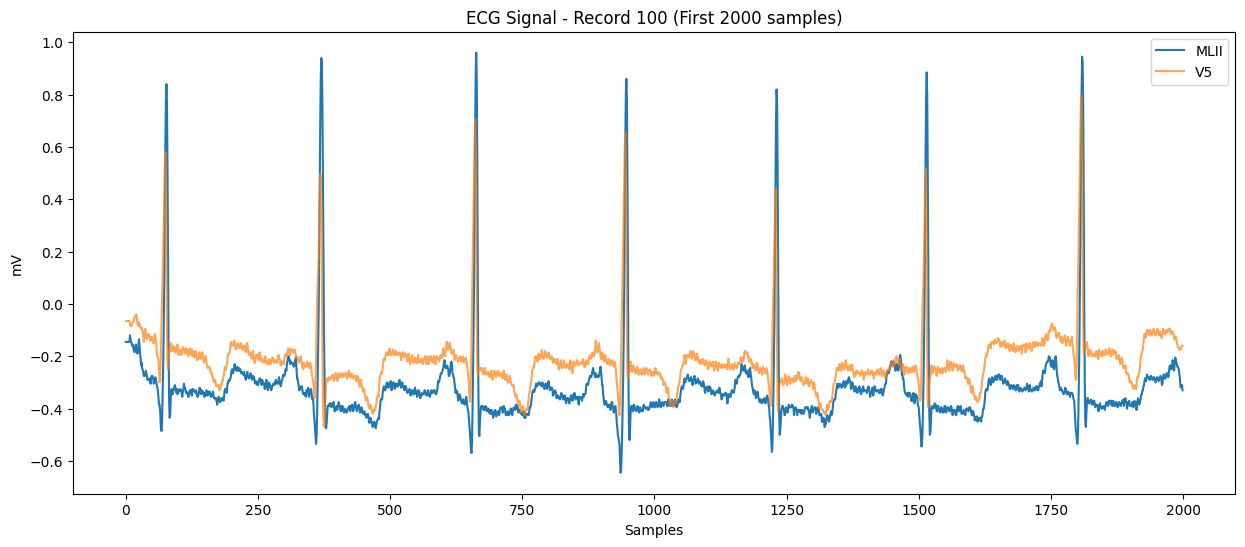

In [5]:
sample_record = wfdb.rdrecord(os.path.join(data_path, '100'))
plt.figure(figsize=(15, 6))
plt.plot(sample_record.p_signal[:2000, 0], label=sample_record.sig_name[0])
plt.plot(sample_record.p_signal[:2000, 1], label=sample_record.sig_name[1], alpha=0.7)
plt.title('ECG Signal - Record 100 (First 2000 samples)')
plt.legend()
plt.xlabel('Samples')
plt.ylabel('mV')
plt.show()

### 3. Annotation Distribution
Understanding the distribution of beat types (Normal vs. Arrhythmia) is critical for handling class imbalance.

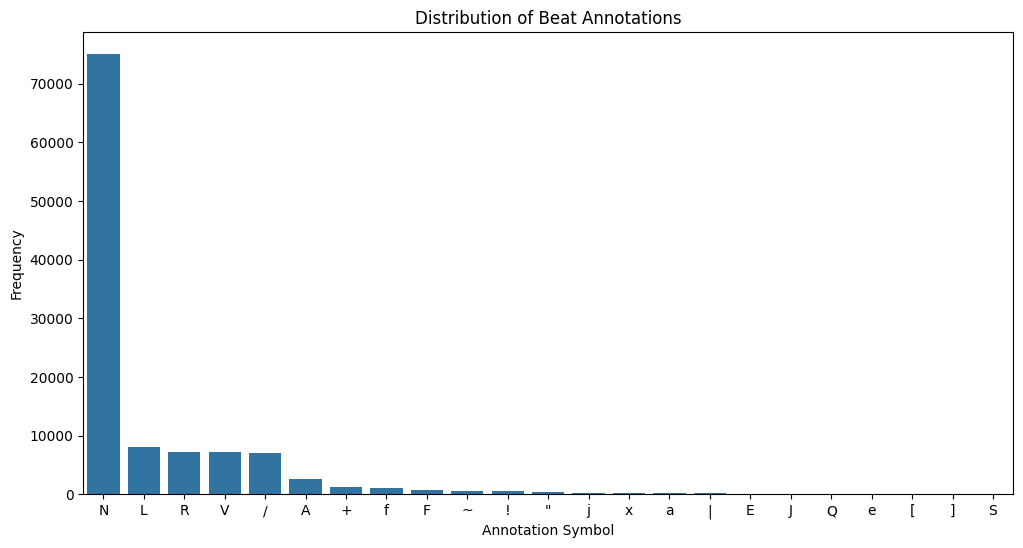

Annotation counts:
N    75052
L     8075
R     7259
V     7130
/     7028
A     2546
+     1291
f      982
F      803
~      616
!      472
"      437
j      229
x      193
a      150
|      132
E      106
J       83
Q       33
e       16
[        6
]        6
S        2
Name: count, dtype: int64


In [6]:
all_ann = []
for rec_id in records:
    ann = wfdb.rdann(os.path.join(data_path, rec_id), 'atr')
    all_ann.extend(ann.symbol)

ann_counts = pd.Series(all_ann).value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=ann_counts.index, y=ann_counts.values)
plt.title('Distribution of Beat Annotations')
plt.xlabel('Annotation Symbol')
plt.ylabel('Frequency')
plt.show()

print("Annotation counts:")
print(ann_counts)

### 4. RR Interval and Class Imbalance Analysis
We will analyze the heart rate variability and visualize the mapping to AAMI standard classes to address the class imbalance.

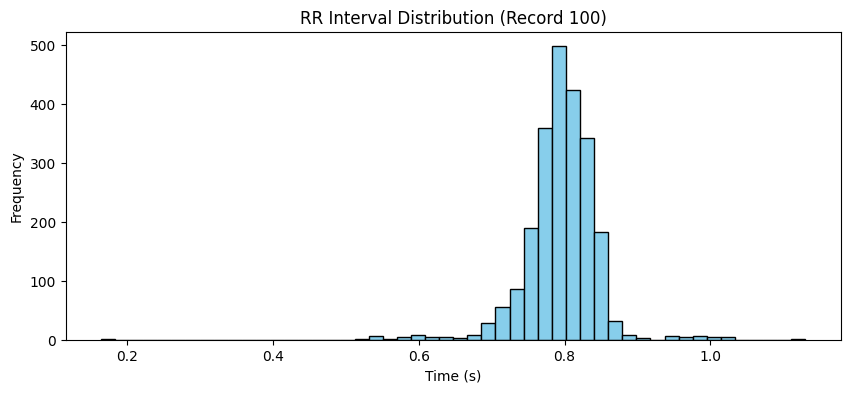

In [17]:
sample_ann = wfdb.rdann(os.path.join(data_path, '100'), 'atr')
rr_intervals = np.diff(sample_ann.sample) / 360.0

plt.figure(figsize=(10, 4))
plt.hist(rr_intervals, bins=50, color='skyblue', edgecolor='black')
plt.title('RR Interval Distribution (Record 100)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency')
plt.show()

### 5. Preprocessing & AAMI Mapping
We map the 23 original labels into 5 AAMI categories (N, S, V, F, Q) and segment each beat into 360-sample windows.

In [18]:
aami_map = {'N':'N','L':'N','R':'N','e':'N','j':'N','A':'S','a':'S','J':'S','S':'S','V':'V','E':'V','F':'F','/':'Q','f':'Q','Q':'Q'}

def segment_beats(records, data_path, window=180):
    X, y = [], []
    for rec in records:
        record = wfdb.rdrecord(os.path.join(data_path, rec))
        ann = wfdb.rdann(os.path.join(data_path, rec), 'atr')
        sig = (record.p_signal[:,0] - np.mean(record.p_signal[:,0])) / np.std(record.p_signal[:,0])
        for idx, sym in zip(ann.sample, ann.symbol):
            if sym in aami_map and window < idx < len(sig)-window:
                X.append(sig[idx-window:idx+window])
                y.append(aami_map[sym])
    return np.array(X), np.array(y)

X, y = segment_beats(records, data_path)
print(f"Segmented {len(X)} beats. Distribution: {pd.Series(y).value_counts().to_dict()}")

Segmented 109437 beats. Distribution: {'N': 90581, 'Q': 8038, 'V': 7235, 'S': 2781, 'F': 802}


### 6. Training and Evaluation
Training ML models and a 1D CNN, then displaying performance metrics and confusion matrices.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

le = LabelEncoder()
y_enc = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)

def evaluate(name, y_true, y_pred):
    print(f"\n--- {name} ---\nAccuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

# Classifiers
lr = LogisticRegression(max_iter=500).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=50).fit(X_train, y_train)
# Training SVM on subset for efficiency in Colab environment
svm = SVC(kernel='rbf', probability=True).fit(X_train[:15000], y_train[:15000])
xgb = XGBClassifier().fit(X_train, y_train)

# 1D CNN
cnn = tf.keras.models.Sequential([
    tf.keras.layers.Reshape((360, 1), input_shape=(360,)),
    tf.keras.layers.Conv1D(64, 5, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.fit(X_train, y_train, epochs=3, batch_size=64, verbose=0)

# Results
evaluate("Logistic Regression", y_test, lr.predict(X_test))
evaluate("Random Forest", y_test, rf.predict(X_test))
evaluate("SVM", y_test, svm.predict(X_test))
evaluate("XGBoost", y_test, xgb.predict(X_test))
y_cnn = np.argmax(cnn.predict(X_test), axis=1)
evaluate("1D CNN", y_test, y_cnn)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Logistic Regression ---
Accuracy: 0.9333
              precision    recall  f1-score   support

           F       0.65      0.40      0.50       160
           N       0.95      0.98      0.96     18117
           Q       0.94      0.88      0.91      1608
           S       0.81      0.49      0.61       556
           V       0.77      0.60      0.67      1447

    accuracy                           0.93     21888
   macro avg       0.83      0.67      0.73     21888
weighted avg       0.93      0.93      0.93     21888


--- Random Forest ---
Accuracy: 0.9824
              precision    recall  f1-score   support

           F       0.94      0.64      0.76       160
           N       0.98      1.00      0.99     18117
           Q       1.00      0.97      0.98      1608
           S       0.98      0.71      0.83       556
           V       0.97      0.94      0.95      1447

    accuracy                           0.98     21888
   macro avg       0.97      0.85      0.90  

### 7. Final Results: Confusion Matrices and ROC Curves
We will now visualize the performance of all models using confusion matrices and multi-class ROC curves to analyze class-wise performance and threshold trade-offs.

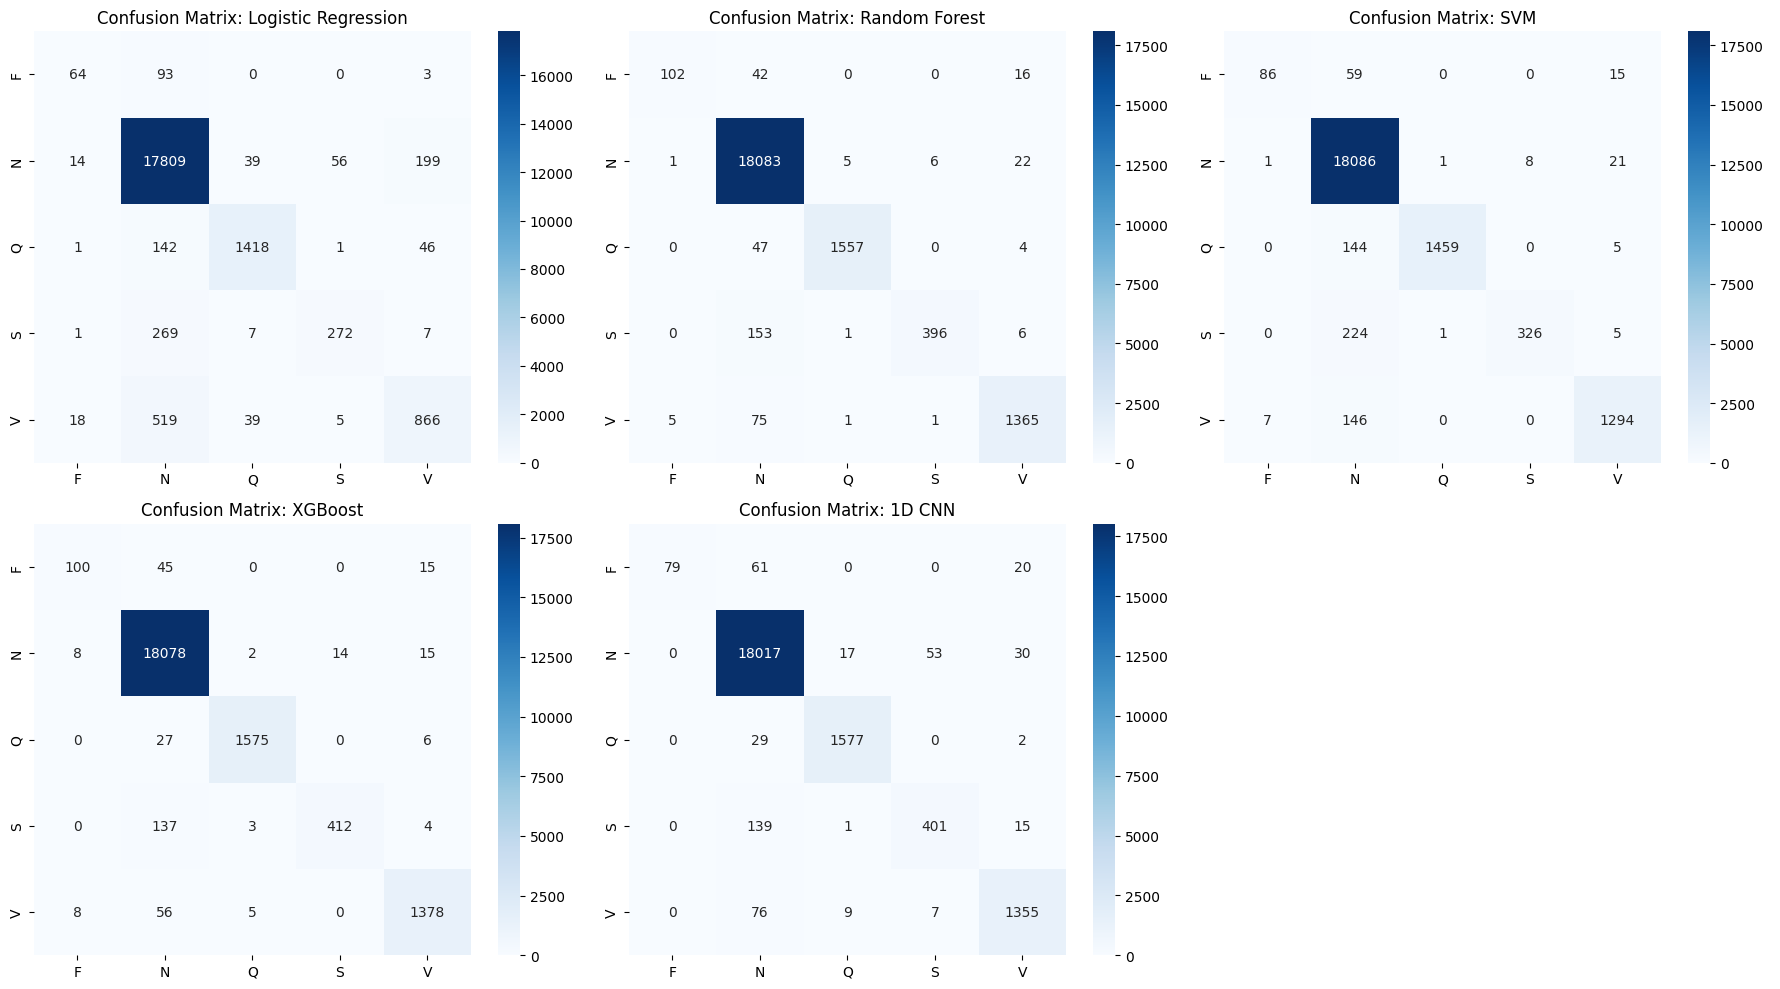

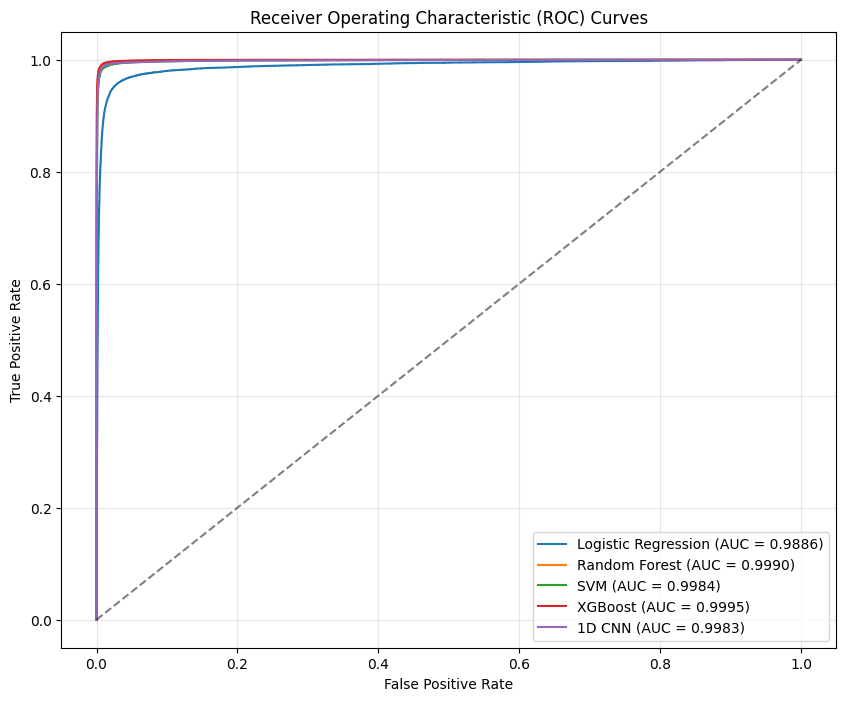

In [32]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_final_results(models_dict, X_test, y_test, le):
    # 1. Plot Confusion Matrices
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, (name, model) in enumerate(models_dict.items()):
        if name == "1D CNN":
            y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        else:
            y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=le.classes_, yticklabels=le.classes_)
        axes[i].set_title(f'Confusion Matrix: {name}')

    if len(models_dict) < len(axes):
        for j in range(len(models_dict), len(axes)):
            axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # 2. Plot ROC Curves (Multiclass Macro Average)
    y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
    plt.figure(figsize=(10, 8))

    for name, model in models_dict.items():
        if name == "1D CNN":
            y_score = model.predict(X_test, verbose=0)
        else:
            y_score = model.predict_proba(X_test)

        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

models_to_eval = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb,
    "1D CNN": cnn
}

plot_final_results(models_to_eval, X_test, y_test, le)

## Interpretation and Limitations

The tree-based models give the strongest results in this experiment, with XGBoost reaching
about 98.4% accuracy and Random Forest about 98.2% on the recorded beat-level test split.
Performance is lower for the smaller F and S classes, which is important because the dataset
is highly imbalanced.

These results should be interpreted as a portfolio baseline. Beats from the same record can
appear in both training and test sets under a beat-level random split. A stronger future
evaluation would use a patient- or record-independent split and external validation.
